In [840]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Start of the Pipeline

In [841]:
dtr = pd.read_csv('../results/DTR.csv')
gru= pd.read_csv('../results/GRU.csv')
lgbm = pd.read_csv('../results/LGBM.csv')
lstm = pd.read_csv('../results/LSTM.csv')
mlp = pd.read_csv('../results/MLP.csv')
padt_A = pd.read_csv('../results/PADT-A.csv')
padt_B = pd.read_csv('../results/PADT-B.csv')
rf_padt_B = pd.read_csv('../results/RF_PADT-B.csv')
rf = pd.read_csv('../results/RF.csv')
svr = pd.read_csv('../results/SVR.csv')
xgbr = pd.read_csv('../results/XGBR.csv')
co2 = pd.read_csv('../../data/clean/others/co2_levels.csv')

In [842]:
co2["date"] = pd.to_datetime(co2["date"], format="%Y-%m-%d")
print(co2["date"].min())
print(co2["date"].max())
print(co2.shape)

print(co2[["date"]].head())
print(co2[["date"]].tail())

1958-03-01 00:00:00
2024-11-01 00:00:00
(801, 2)
        date
0 1958-03-01
1 1958-04-01
2 1958-05-01
3 1958-06-01
4 1958-07-01
          date
796 2024-07-01
797 2024-08-01
798 2024-09-01
799 2024-10-01
800 2024-11-01


##### DTR

In [843]:
target_DTR_co2 = dtr.loc[ (dtr['series_name'] == 'co2_levels'),'target']
prediction_DTR_co2 = dtr.loc[(dtr['series_name'] == 'co2_levels'),'pred']

In [844]:
DTR_co2 = dtr[ (dtr['series_name'] == 'co2_levels')]
DTR_co2_train = DTR_co2.loc[DTR_co2['Phase'] == 'train', ['target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
DTR_co2_val = DTR_co2.loc[DTR_co2['Phase'] == 'val', ['target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()


In [845]:
DTR_co2_val_pred = DTR_co2_val['pred']
DTR_co2_val_target = DTR_co2_val['target']
DTR_co2_val_ae = DTR_co2_val['AE']
DTR_co2_val_ae_tipo = DTR_co2_val[['AE','Phase']]
DTR_co2_val_se = DTR_co2_val[['SE','Phase']]
DTR_co2_val_ape = DTR_co2_val[['APE','Phase']]

In [846]:
DTR_co2_train_pred = DTR_co2_train['pred']
DTR_co2_train_target = DTR_co2_train['target']
DTR_co2_train_ae = DTR_co2_train['AE']
DTR_co2_train_ae_tipo = DTR_co2_train[['AE','Phase']]
DTR_co2_train_se = DTR_co2_train[['SE','Phase']]
DTR_co2_train_ape = DTR_co2_train[['APE','Phase']]

In [847]:
DTR_co2_erros_ae= pd.concat([DTR_co2_val_ae_tipo, DTR_co2_train_ae_tipo])
DTR_co2_erros_se= pd.concat([DTR_co2_val_se, DTR_co2_train_se])
DTR_co2_erros_ape= pd.concat([DTR_co2_val_ape, DTR_co2_train_ape])


##### GRU

In [848]:
target_GRU_co2 = gru.loc[ (gru['series_name'] == 'co2_levels'),'target']
prediction_GRU_co2 = gru.loc[(gru['series_name'] == 'co2_levels'),'pred']

In [849]:
gru_co2 = gru[ (gru['series_name'] == 'co2_levels')]
gru_co2_train = gru_co2.loc[gru_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
gru_co2_val = gru_co2.loc[gru_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()  

In [850]:
GRU_co2_train_pred = gru_co2_train['pred']
GRU_co2_train_target = gru_co2_train['target']
GRU_co2_train_ae = gru_co2_train['AE']
GRU_co2_train_ae_tipo = gru_co2_train[['AE','Phase']]
GRU_co2_train_se = gru_co2_train[['SE','Phase']]
GRU_co2_train_ape = gru_co2_train[['APE','Phase']]



In [851]:
GRU_co2_val_pred = gru_co2_val['pred']
GRU_co2_val_target = gru_co2_val['target']
GRU_co2_val_ae = gru_co2_val['AE']
GRU_co2_val_ae_tipo = gru_co2_val[['AE','Phase', 'model']]
GRU_co2_val_se = gru_co2_val[['SE','Phase','model']]
GRU_co2_val_ape = gru_co2_val[['APE','Phase','model']]

In [852]:
GRU_co2_erros_ae= pd.concat([GRU_co2_val_ae_tipo, GRU_co2_train_ae_tipo])
GRU_co2_erros_se= pd.concat([GRU_co2_val_se, GRU_co2_train_se])
GRU_co2_erros_ape= pd.concat([GRU_co2_val_ape, GRU_co2_train_ape])  

##### LGBM

In [853]:
target_LGBM_co2 = lgbm.loc[ (lgbm['series_name'] == 'co2_levels'),'target']
prediction_LGBM_co2 = lgbm.loc[(lgbm['series_name'] == 'co2_levels'),'pred']

In [854]:
lgbm_co2 = lgbm[ (lgbm['series_name'] == 'co2_levels')]
lgbm_co2_train = lgbm_co2.loc[lgbm_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
lgbm_co2_val = lgbm_co2.loc[lgbm_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy() 

In [855]:
LGBM_co2_train_pred = lgbm_co2_train['pred']
LGBM_co2_train_target = lgbm_co2_train['target']    
LGBM_co2_train_ae = lgbm_co2_train['AE']
LGBM_co2_train_ae_tipo = lgbm_co2_train[['AE','Phase']]
LGBM_co2_train_se = lgbm_co2_train[['SE','Phase']]
LGBM_co2_train_ape = lgbm_co2_train[['APE','Phase']]    


In [856]:
LGBM_co2_train_val = lgbm_co2_val['pred']
LGBM_co2_val_target = lgbm_co2_val['target']
LGBM_co2_val_ae = lgbm_co2_val['AE']
LGBM_co2_val_ae_tipo = lgbm_co2_val[['AE','Phase', 'model']]
LGBM_co2_val_se = lgbm_co2_val[['SE','Phase','model']]
LGBM_co2_val_ape = lgbm_co2_val[['APE','Phase','model']]

In [857]:
LGBM_co2_erros_ae = pd.concat([LGBM_co2_val_ae_tipo, LGBM_co2_train_ae_tipo])
LGBM_co2_erros_se = pd.concat([LGBM_co2_val_se, LGBM_co2_train_se])
LGBM_co2_erros_ape = pd.concat([LGBM_co2_val_ape, LGBM_co2_train_ape])

##### LSTM

In [858]:
target_LSTM_co2 = lstm.loc[ (lstm['series_name'] == 'co2_levels'),'target']
prediction_LSTM_co2 = lstm.loc[(lstm['series_name'] == 'co2_levels'),'pred']

In [859]:
lstm_co2 = lstm[ (lstm['series_name'] == 'co2_levels')]
lstm_co2_train = lstm_co2.loc[lstm_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
lstm_co2_val = lstm_co2.loc[lstm_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()   

In [860]:
LSTM_co2_train_pred = lstm_co2_train['pred']
LSTM_co2_train_target = lstm_co2_train['target']
LSTM_co2_train_ae = lstm_co2_train['AE']
LSTM_co2_train_ae_tipo = lstm_co2_train[['AE','Phase', 'model']]
LSTM_co2_train_se = lstm_co2_train[['SE','Phase','model']]
LSTM_co2_train_ape = lstm_co2_train[['APE','Phase','model']]


In [861]:
lstm_co2_val_pred = lstm_co2_val['pred']
LSTM_co2_val_target = lstm_co2_val['target']
LSTM_co2_val_ae = lstm_co2_val['AE']
LSTM_co2_val_ae_tipo = lstm_co2_val[['AE','Phase', 'model']]
LSTM_co2_val_se = lstm_co2_val[['SE','Phase','model']]
LSTM_co2_val_ape = lstm_co2_val[['APE','Phase','model']]

In [862]:
LSTM_co2_erros_ae = pd.concat([LSTM_co2_val_ae_tipo, LSTM_co2_train_ae_tipo])
LSTM_co2_erros_se = pd.concat([LSTM_co2_val_se, LSTM_co2_train_se])
LSTM_co2_erros_ape = pd.concat([LSTM_co2_val_ape, LSTM_co2_train_ape])

##### MLP

In [863]:
target_MLP_co2 = mlp.loc[ (mlp['series_name'] == 'co2_levels'),'target']
prediction_MLP_co2 = mlp.loc[(mlp['series_name'] == 'co2_levels'),'pred']

In [864]:
mlp_co2 = mlp[ (mlp['series_name'] == 'co2_levels')]
mlp_co2_train = mlp_co2.loc[mlp_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
mlp_co2_val = mlp_co2.loc[mlp_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()   

In [865]:
mlp_co2_train_pred = mlp_co2_train['pred']
mlp_co2_train_target = mlp_co2_train['target']
mlp_co2_train_ae = mlp_co2_train['AE']
mlp_co2_train_ae_tipo = mlp_co2_train[['AE','Phase']]
mlp_co2_train_se = mlp_co2_train[['SE','Phase']]
mlp_co2_train_ape = mlp_co2_train[['APE','Phase']]


In [866]:
mlp_co2_val_pred = mlp_co2_val['pred']
mlp_co2_val_target = mlp_co2_val['target']
mlp_co2_val_ae = mlp_co2_val['AE']
mlp_co2_val_ae_tipo = mlp_co2_val[['AE','Phase','model']]
mlp_co2_val_se = mlp_co2_val[['SE','Phase','model']]
mlp_co2_val_ape = mlp_co2_val[['APE','Phase','model']]

In [867]:
mlp_co2_erros_ae = pd.concat([mlp_co2_val_ae_tipo, mlp_co2_train_ae_tipo])
mlp_co2_erros_se = pd.concat([mlp_co2_val_se, mlp_co2_train_se])
mlp_co2_erros_ape = pd.concat([mlp_co2_val_ape, mlp_co2_train_ape])

##### PADT-A

In [868]:
target_padt_A_co2 = padt_A.loc[ (padt_A['series_name'] == 'co2_levels'),'target']
prediction_padt_A_co2 = padt_A.loc[(padt_A['series_name'] == 'co2_levels'),'pred']

In [869]:
padt_A_co2 = padt_A[ (padt_A['series_name'] == 'co2_levels')]
padt_A_co2_train = padt_A_co2.loc[padt_A_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
padt_A_co2_val = padt_A_co2.loc[padt_A_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()     

In [870]:
padt_A_co2_train_pred = padt_A_co2_train['pred']
padt_A_co2_train_target = padt_A_co2_train['target']
padt_A_co2_train_ae = padt_A_co2_train['AE']
padt_A_co2_train_ae_tipo = padt_A_co2_train[['AE','Phase', 'model']] 
padt_A_co2_train_se = padt_A_co2_train[['SE','Phase','model']]
padt_A_co2_train_ape = padt_A_co2_train[['APE','Phase','model']]   

In [871]:
padt_A_co2_val_pred = padt_A_co2_val['pred']
padt_A_co2_val_target = padt_A_co2_val['target']
padt_A_co2_val_ae = padt_A_co2_val['AE']
padt_A_co2_val_ae_tipo = padt_A_co2_val[['AE','Phase', 'model']]
padt_A_co2_val_se = padt_A_co2_val[['SE','Phase','model']]  
padt_A_co2_val_ape = padt_A_co2_val[['APE','Phase','model']]

In [872]:
padt_A_co2_erros_ae = pd.concat([padt_A_co2_val_ae_tipo, padt_A_co2_train_ae_tipo])
padt_A_co2_erros_se = pd.concat([padt_A_co2_val_se, padt_A_co2_train_se])
padt_A_co2_erros_ape = pd.concat([padt_A_co2_val_ape, padt_A_co2_train_ape]) 

##### PADT-B

In [873]:
target_PADT_B_co2 = padt_B.loc[ (padt_B['series_name'] == 'co2_levels'),'target']
prediction_PADT_B_co2 = padt_B.loc[(padt_B['series_name'] == 'co2_levels'),'pred']

In [874]:
padt_B_co2 = padt_B[ (padt_B['series_name'] == 'co2_levels')]
padt_B_co2_train = padt_B_co2.loc[padt_B_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
padt_B_co2_val = padt_B_co2.loc[padt_B_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy() 

In [875]:
padt_B_co2_train_pred = padt_B_co2_train['pred']
padt_B_co2_train_target = padt_B_co2_train['target']
padt_B_co2_train_ae = padt_B_co2_train['AE']
padt_B_co2_train_ae_tipo = padt_B_co2_train[['AE','Phase', 'model']]
padt_B_co2_train_se = padt_B_co2_train[['SE','Phase','model']]
padt_B_co2_train_ape = padt_B_co2_train[['APE','Phase','model']]

In [876]:
padt_B_co2_val_pred = padt_B_co2_val['pred']
padt_B_co2_val_target = padt_B_co2_val['target']
padt_B_co2_val_ae = padt_B_co2_val['AE']
padt_B_co2_val_ae_tipo = padt_B_co2_val[['AE','Phase', 'model']]
padt_B_co2_val_se = padt_B_co2_val[['SE','Phase','model']]  
padt_B_co2_val_ape = padt_B_co2_val[['APE','Phase','model']]

In [877]:
padt_B_co2_erros_ae = pd.concat([padt_B_co2_val_ae_tipo, padt_B_co2_train_ae_tipo])
padt_B_co2_erros_se = pd.concat([padt_B_co2_val_se, padt_B_co2_train_se])
padt_B_co2_erros_ape = pd.concat([padt_B_co2_val_ape, padt_B_co2_train_ape])

##### RF_PADT-B

In [878]:
target_RF_PADT_B_co2 = rf_padt_B.loc[ (rf_padt_B['series_name'] == 'co2_levels'),'target']
prediction_RF_PADT_B_co2 = rf_padt_B.loc[(rf_padt_B['series_name'] == 'co2_levels'),'pred']

In [879]:
rf_padt_B_co2 = rf_padt_B[ (rf_padt_B['series_name'] == 'co2_levels')]
rf_padt_B_co2_train = rf_padt_B_co2.loc[rf_padt_B_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()       
rf_padt_B_co2_val= rf_padt_B_co2.loc[rf_padt_B_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()

In [880]:
rf_padt_B_co2_train_pred = rf_padt_B_co2_train['pred']
rf_padt_B_co2_train_target = rf_padt_B_co2_train['target']
rf_padt_B_co2_train_ae = rf_padt_B_co2_train['AE']
rf_padt_B_co2_train_ae_tipo = rf_padt_B_co2_train[['AE','Phase', 'model']]
rf_padt_B_co2_train_se = rf_padt_B_co2_train[['SE','Phase','model']]
rf_padt_B_co2_train_ape = rf_padt_B_co2_train[['APE','Phase','model']]

In [881]:
rf_padt_B_co2_val_pred = rf_padt_B_co2_val['pred']
rf_padt_B_co2_val_target = rf_padt_B_co2_val['target']  
rf_padt_B_co2_val_ae = rf_padt_B_co2_val['AE']
rf_padt_B_co2_val_ae_tipo = rf_padt_B_co2_val[['AE','Phase', 'model']]
rf_padt_B_co2_val_se = rf_padt_B_co2_val[['SE','Phase','model']]
rf_padt_B_co2_val_ape = rf_padt_B_co2_val[['APE','Phase','model']]

In [882]:
rf_padt_B_co2_erros_ae = pd.concat([rf_padt_B_co2_val_ae_tipo, rf_padt_B_co2_train_ae_tipo])
rf_padt_B_co2_erros_se = pd.concat([rf_padt_B_co2_val_se, rf_padt_B_co2_train_se])
rf_padt_B_co2_erros_ape = pd.concat([rf_padt_B_co2_val_ape, rf_padt_B_co2_train_ape])

##### RF

In [883]:
target_RF_co2 = rf.loc[ (rf['series_name'] == 'co2_levels'),'target']
prediction_RF_co2 = rf.loc[(rf['series_name'] == 'co2_levels'),'pred']

In [884]:
rf_co2 = rf[ (rf['series_name'] == 'co2_levels')]
rf_co2_train = rf_co2.loc[rf_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
rf_co2_val = rf_co2.loc[rf_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy() 

In [885]:
rf_co2_train_pred = rf_co2_train['pred']
rf_co2_train_target = rf_co2_train['target']
rf_co2_train_ae = rf_co2_train['AE']
rf_co2_train_ae_tipo = rf_co2_train[['AE','Phase', 'model']]
rf_co2_train_se = rf_co2_train[['SE','Phase','model']]
rf_co2_train_ape = rf_co2_train[['APE','Phase','model']]

In [886]:
rf_co2_val_pred = rf_co2_val['pred']
rf_co2_val_target = rf_co2_val['target']
rf_co2_val_ae = rf_co2_val['AE']
rf_co2_val_ae_tipo = rf_co2_val[['AE','Phase', 'model']]
rf_co2_val_se = rf_co2_val[['SE','Phase','model']]
rf_co2_val_ape = rf_co2_val[['APE','Phase','model']]
   

In [887]:
rf_co2_erros_ae = pd.concat([rf_co2_val_ae_tipo, rf_co2_train_ae_tipo])
rf_co2_erros_se = pd.concat([rf_co2_val_se, rf_co2_train_se])
rf_co2_erros_ape = pd.concat([rf_co2_val_ape, rf_co2_train_ape]) 

##### SVR

In [888]:
target_SVR_co2 = svr.loc[ (svr['series_name'] == 'co2_levels'),'target']
prediction_SVR_co2 = svr.loc[(svr['series_name'] == 'co2_levels'),'pred']

In [889]:
svr_co2 = svr[ (svr['series_name'] == 'co2_levels')]
svr_co2_train = svr_co2.loc[svr_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
svr_co2_val = svr_co2.loc[svr_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()  

In [890]:
svr_co2_train_pred = svr_co2_train['pred']
svr_co2_train_target = svr_co2_train['target']
svr_co2_train_ae = svr_co2_train['AE']
svr_co2_train_ae_tipo = svr_co2_train[['AE','Phase', 'model']]
svr_co2_train_se = svr_co2_train[['SE','Phase','model']]
svr_co2_train_ape = svr_co2_train[['APE','Phase','model']]

In [891]:
svr_co2_val_pred = svr_co2_val['pred']
svr_co2_val_target = svr_co2_val['target']
svr_co2_val_ae = svr_co2_val['AE']
svr_co2_val_ae_tipo = svr_co2_val[['AE','Phase', 'model']]
svr_co2_val_se = svr_co2_val[['SE','Phase','model']]
svr_co2_val_ape = svr_co2_val[['APE','Phase','model']]

In [892]:
svr_co2_erros_ae = pd.concat([svr_co2_val_ae_tipo, svr_co2_train_ae_tipo])
svr_co2_erros_se = pd.concat([svr_co2_val_se, svr_co2_train_se])
svr_co2_erros_ape = pd.concat([svr_co2_val_ape, svr_co2_train_ape])

##### XGBR

In [893]:
target_XGBR_co2 = xgbr.loc[ (xgbr['series_name'] == 'co2_levels'),'target']
prediction_XGBR_co2 = xgbr.loc[(xgbr['series_name'] == 'co2_levels'),'pred'] 

In [894]:
xgbr_co2 = xgbr[ (xgbr['series_name'] == 'co2_levels')]
xgbr_co2_train = xgbr_co2.loc[xgbr_co2['Phase'] == 'train', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE'] ].copy()
xgbr_co2_val = xgbr_co2.loc[xgbr_co2['Phase'] == 'val', ['model','target','pred', 'Phase', 'AE', 'SE', 'APE']].copy()

In [895]:
xgbr_co2_train_pred = xgbr_co2_train['pred']
xgbr_co2_train_target = xgbr_co2_train['target']
xgbr_co2_train_ae = xgbr_co2_train['AE']
xgbr_co2_train_ae_tipo = xgbr_co2_train[['AE','Phase', 'model']]
xgbr_co2_train_se = xgbr_co2_train[['SE','Phase','model']]
xgbr_co2_train_ape = xgbr_co2_train[['APE','Phase','model']]

In [896]:
xgbr_co2_val_pred = xgbr_co2_val['pred']
xgbr_co2_val_target = xgbr_co2_val['target']
xgbr_co2_val_ae = xgbr_co2_val['AE']
xgbr_co2_val_ae_tipo = xgbr_co2_val[['AE','Phase', 'model']]
xgbr_co2_val_se = xgbr_co2_val[['SE','Phase','model']]
xgbr_co2_val_ape = xgbr_co2_val[['APE','Phase','model']]

In [897]:
xgbr_co2_erros_ae = pd.concat([xgbr_co2_val_ae_tipo, xgbr_co2_train_ae_tipo])
xgbr_co2_erros_se = pd.concat([xgbr_co2_val_se, xgbr_co2_train_se])
xgbr_co2_erros_ape = pd.concat([xgbr_co2_val_ape, xgbr_co2_train_ape])

##### help

In [898]:
df_all = pd.concat([padt_A_co2_erros_ae, xgbr_co2_erros_ae, svr_co2_erros_ae,rf_co2_erros_ae, rf_padt_B_co2_erros_ae, padt_B_co2_erros_ae, mlp_co2_erros_ae, LSTM_co2_erros_ae, LGBM_co2_erros_ae, GRU_co2_erros_ae, DTR_co2_erros_ae],ignore_index=True)

In [908]:
# co2_reset = co2.reset_index()

# co2_index = pd.merge(
#     DTR_co2,
#     co2_reset,
#     left_on=DTR_co2["index"] + 1,
#     right_on="index",
#     how="inner"
# )
DTR_co2 = DTR_co2.copy()

DTR_co2["date"] = co2.iloc[DTR_co2["index"]]["date"].values

#### Tree Regression Performance

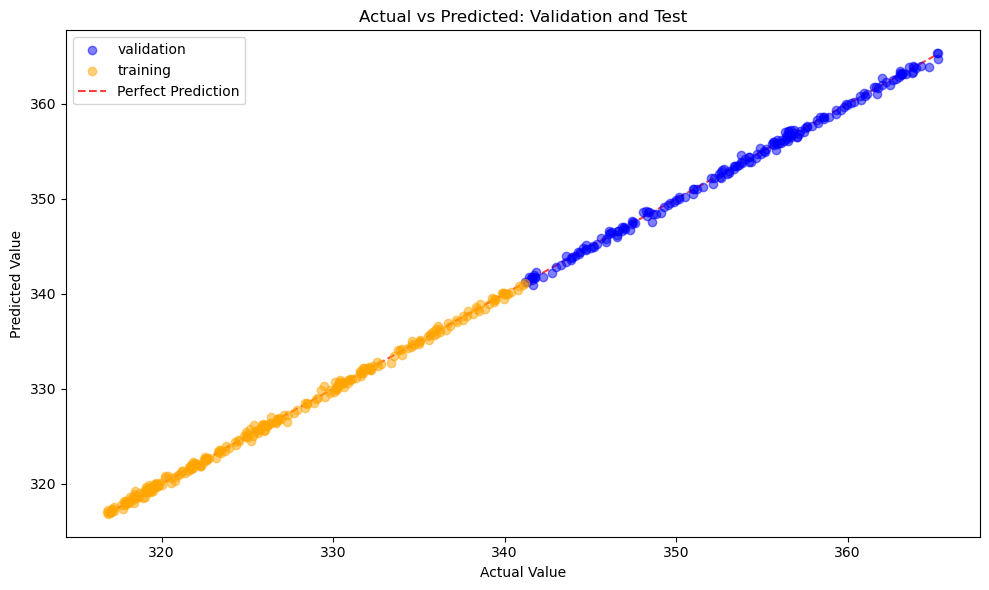

In [900]:
plt.figure(figsize=(10, 6))
plt.scatter(DTR_co2_val_target, DTR_co2_val_pred, alpha=0.5, label='validation', color='blue')
plt.scatter(DTR_co2_train_target, DTR_co2_train_pred, alpha=0.5, label='training', color='orange')

lims = [np.min([DTR_co2_val_target.min(), DTR_co2_train_target.min()]), np.max([DTR_co2_val_target.max(), DTR_co2_train_target.max()])]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted: Validation and Test')
plt.legend()
plt.tight_layout()
plt.show()

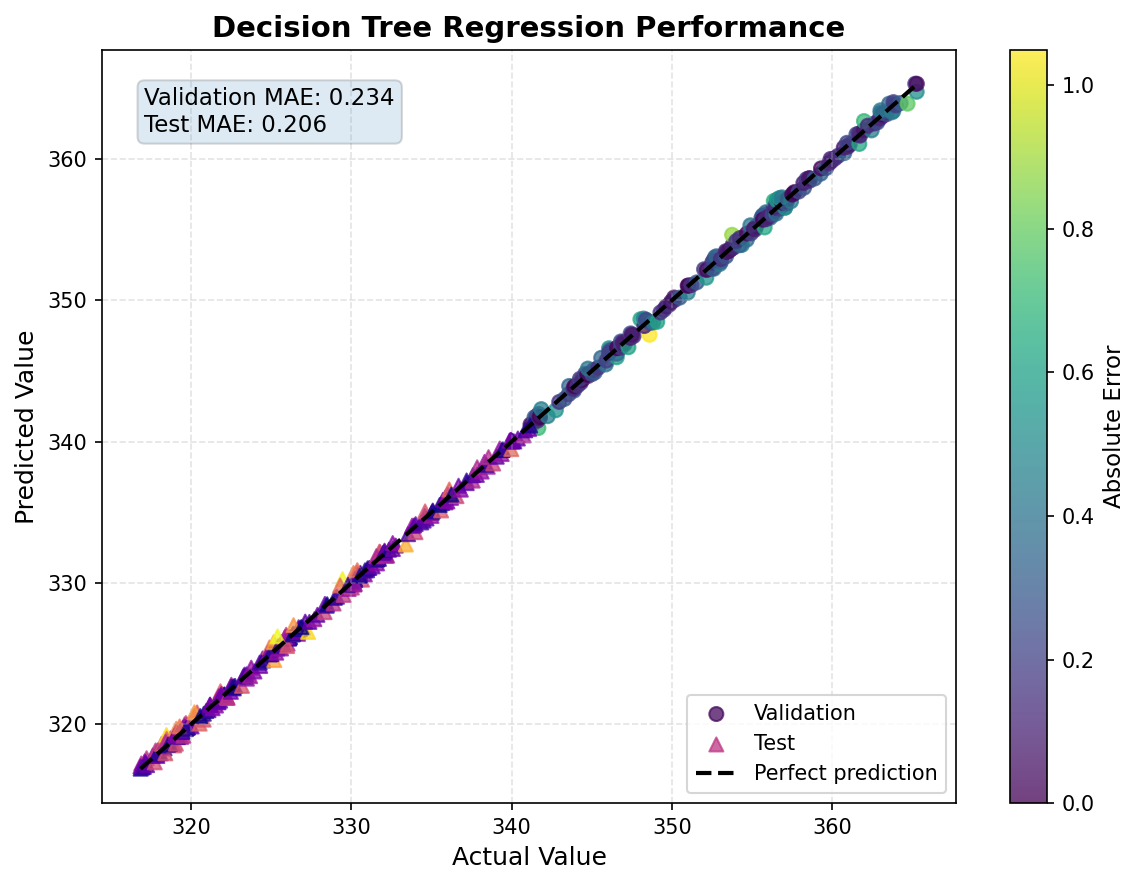

In [901]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Pontos coloridos pelo erro
sc1 = ax.scatter(
    DTR_co2_val_target, DTR_co2_val_pred,
    c=DTR_co2_val_ae,
    cmap="viridis",
    s=45,
    alpha=0.75,
    marker="o",
    label="Validation"
)

sc2 = ax.scatter(
    DTR_co2_train_target, DTR_co2_train_pred,
    c=DTR_co2_train_ae,
    cmap="plasma",
    s=45,
    alpha=0.75,
    marker="^",
    label="Test"
)

# Linha ideal
min_lim = min(DTR_co2_val_target.min(), DTR_co2_train_target.min(), DTR_co2_val_pred.min(), DTR_co2_train_pred.min())
max_lim = max(DTR_co2_val_target.max(), DTR_co2_train_target.max(), DTR_co2_val_pred.max(), DTR_co2_train_pred.max())

ax.plot(
    [min_lim, max_lim],
    [min_lim, max_lim],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Perfect prediction"
)

# Labels e título
ax.set_xlabel("Actual Value", fontsize=12)
ax.set_ylabel("Predicted Value", fontsize=12)
ax.set_title("Decision Tree Regression Performance", fontsize=14, fontweight="bold")

# Grade leve
ax.grid(True, linestyle="--", alpha=0.35)

# Legenda
ax.legend(frameon=True)

# Barra de erro
cbar = plt.colorbar(sc1, ax=ax)
cbar.set_label("Absolute Error", fontsize=11)

# Métricas no gráfico
mae_val = np.mean(DTR_co2_val_ae)
mae_test = np.mean(DTR_co2_train_ae)

text = (
    f"Validation MAE: {mae_val:.3f}\n"
    f"Test MAE: {mae_test:.3f}"
)

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_28596\2233087304.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Phase', y='AE', data=DTR_co2_erros_ae, palette='Set2')


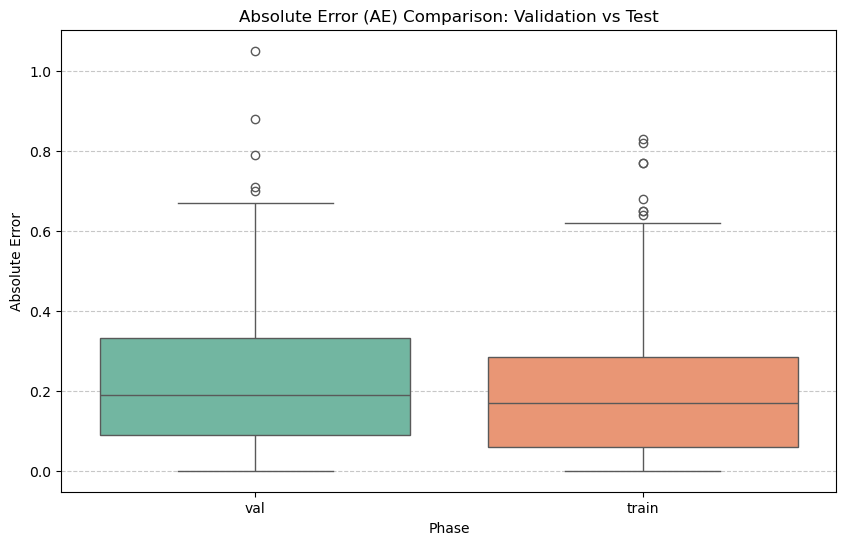

In [902]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Phase', y='AE', data=DTR_co2_erros_ae, palette='Set2')
plt.title('Absolute Error (AE) Comparison: Validation vs Test')
plt.ylabel('Absolute Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_28596\3682244691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


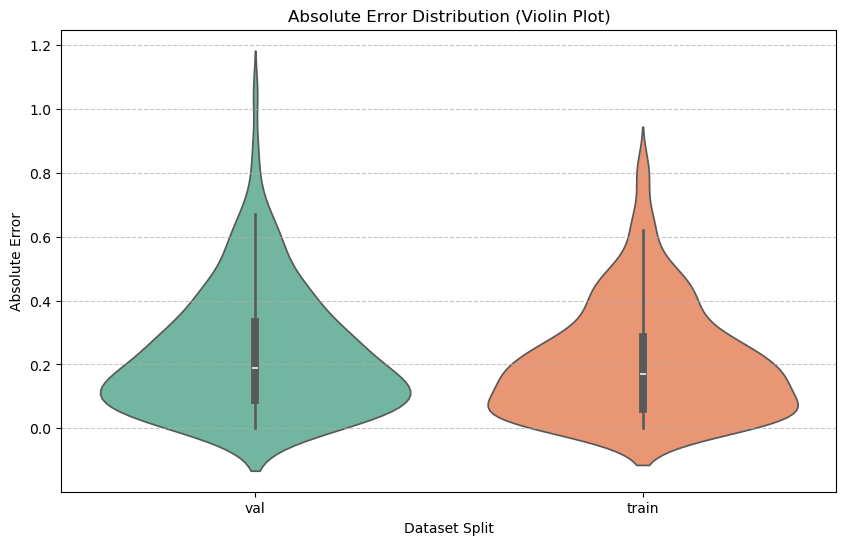

In [903]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    x="Phase",
    y="AE",
    data=DTR_co2_erros_ae,
    palette="Set2"
)

plt.title("Absolute Error Distribution (Violin Plot)")
plt.ylabel("Absolute Error")
plt.xlabel("Dataset Split")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_28596\99805495.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1600x1000 with 0 Axes>

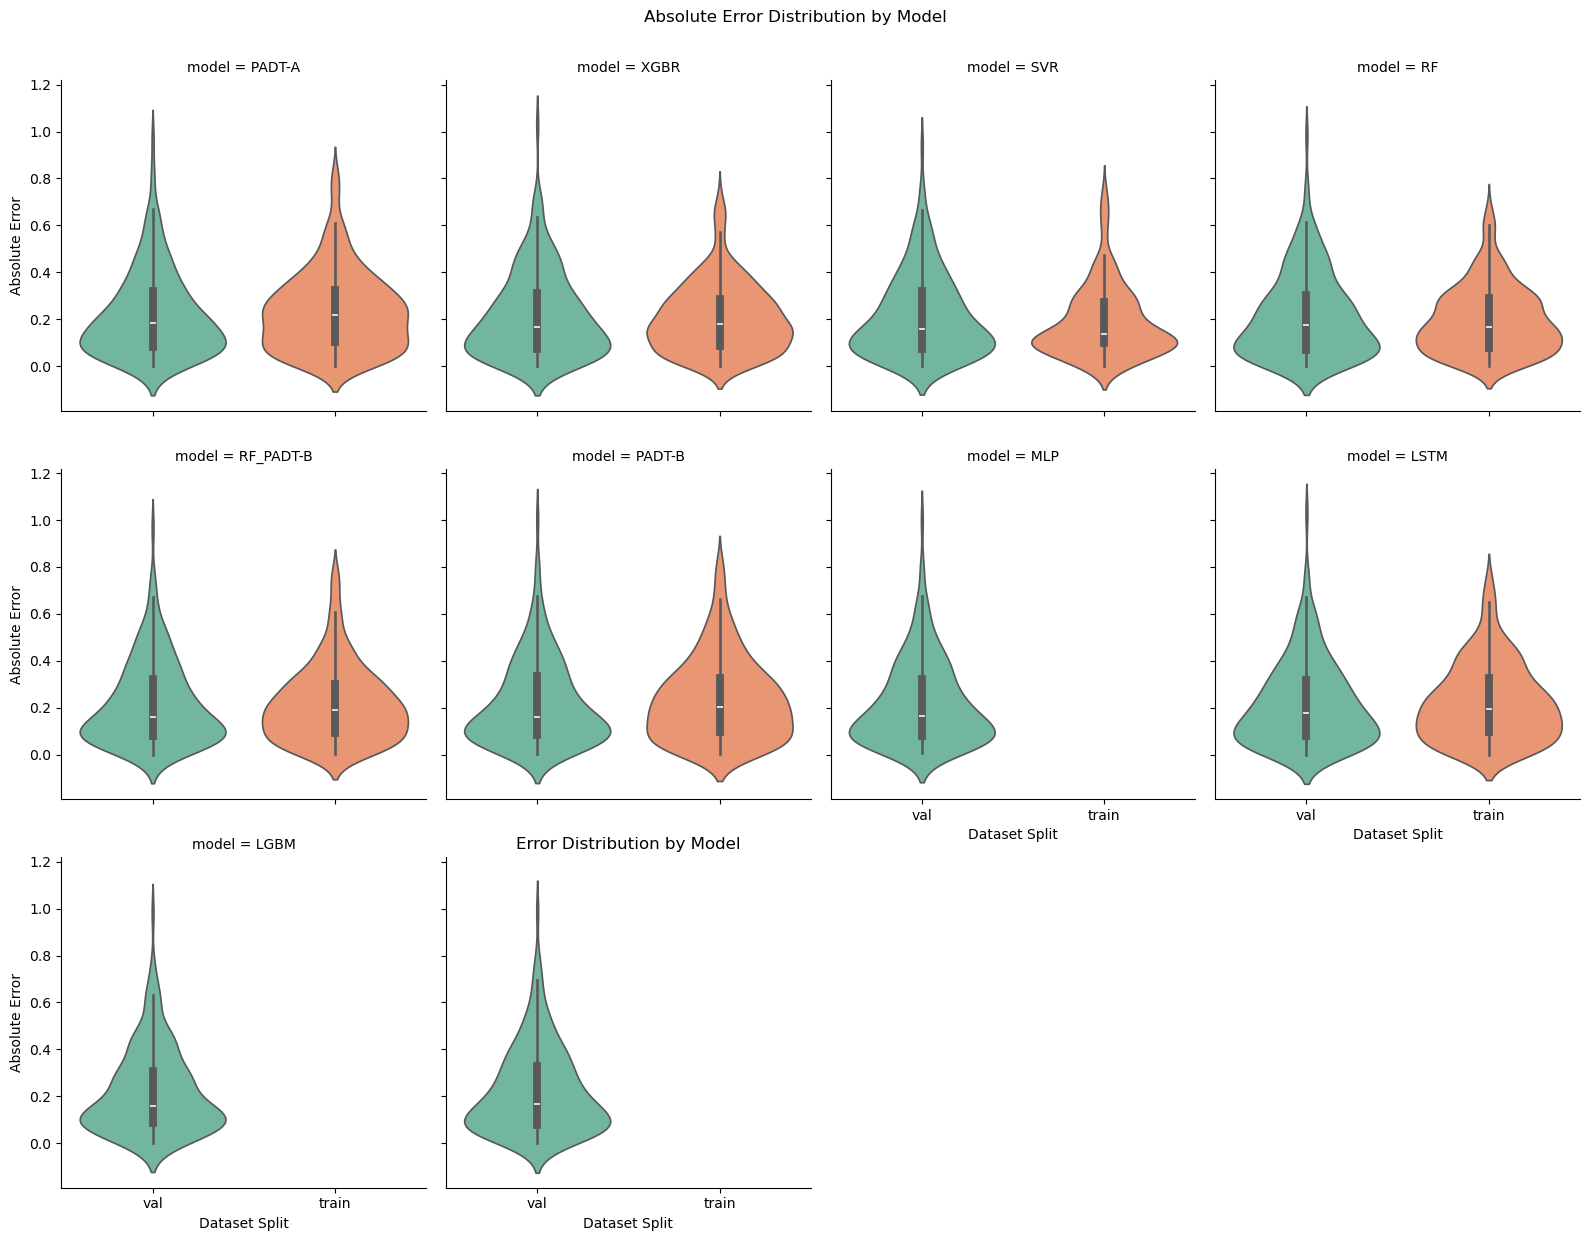

In [904]:
plt.figure(figsize=(16, 10))


g = sns.catplot(
    data=df_all,
    x="Phase",
    y="AE",
    col="model",
    kind="violin",
    col_wrap=4,
    height=4,
    aspect=1,
    palette="Set2",
    inner="box"
)

g.fig.suptitle("Absolute Error Distribution by Model", y=1.03)
g.set_axis_labels("Dataset Split", "Absolute Error")


plt.title("Error Distribution by Model")
plt.show()

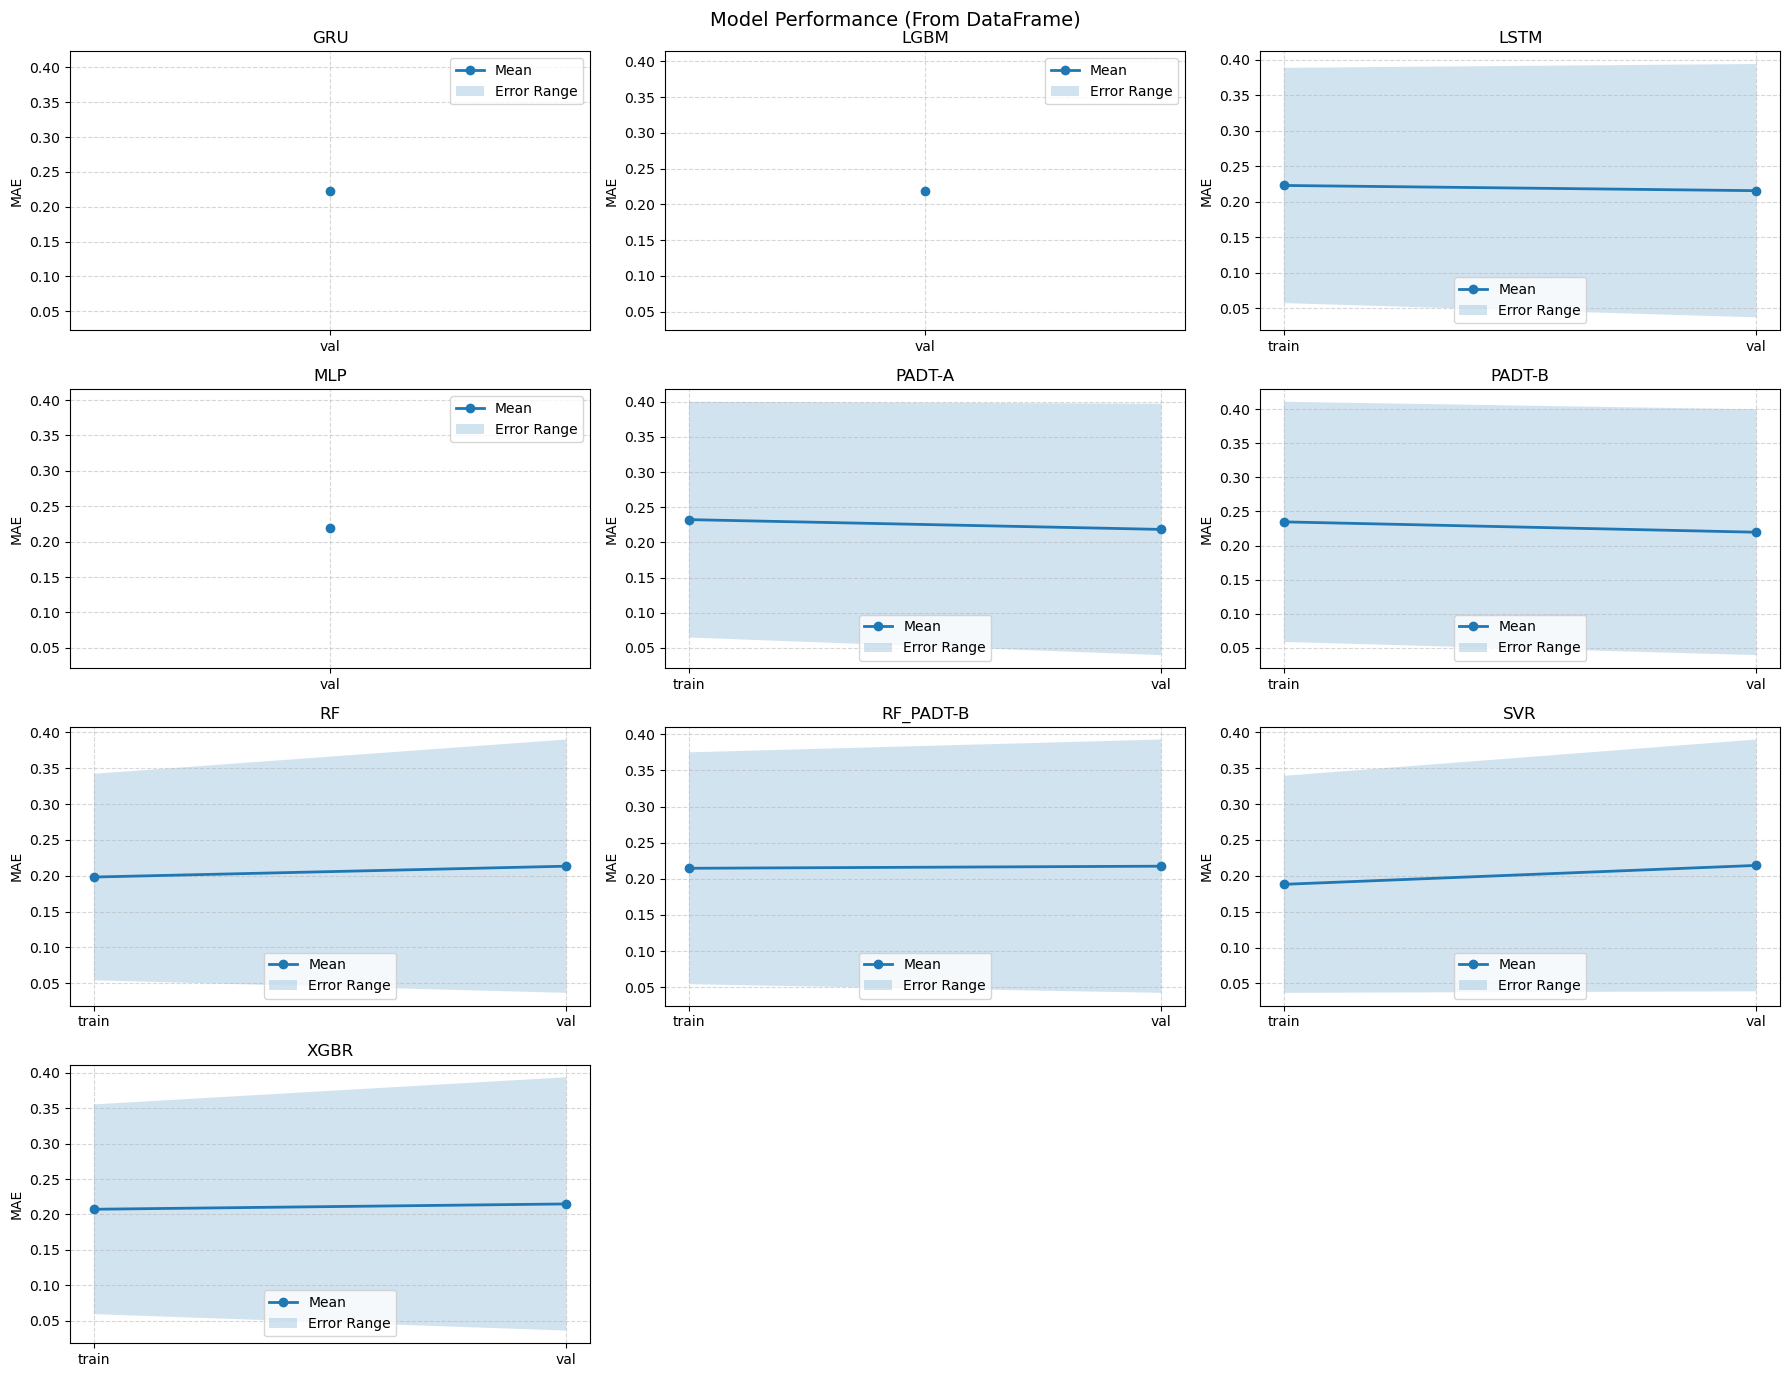

In [905]:
models = ['DTR','GRU','LGBM','LSTM','MLP','PADT-A','PADT-B','RF_PADT-B','RF','SVR','XGBR']

stats = (
    df_all
    .groupby(["model", "Phase"])["AE"]
    .agg(["mean", "std"])
    .reset_index()
)

x_labels = ["train", "val"]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))

axes = axes.flatten()

models = stats["model"].unique()

for i, model in enumerate(models):
    ax = axes[i]

    data_model = stats[stats["model"] == model].copy()

    
    data_model["Phase"] = pd.Categorical(
        data_model["Phase"],
        categories=["train", "val"],
        ordered=True
    )

    data_model = data_model.sort_values("Phase")

    mean = data_model["mean"].values
    std = data_model["std"].fillna(0).values

    x = np.arange(len(mean)) 

    ax.plot(x, mean, marker="o", linewidth=2, label="Mean")

    ax.fill_between(
        x,
        mean - std,
        mean + std,
        alpha=0.2,
        label="Error Range"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(data_model["Phase"])  
    ax.set_title(model)
    ax.set_ylabel("MAE")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

# remove espaços vazios
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Model Performance (From DataFrame)", fontsize=14)
plt.tight_layout()
plt.show()


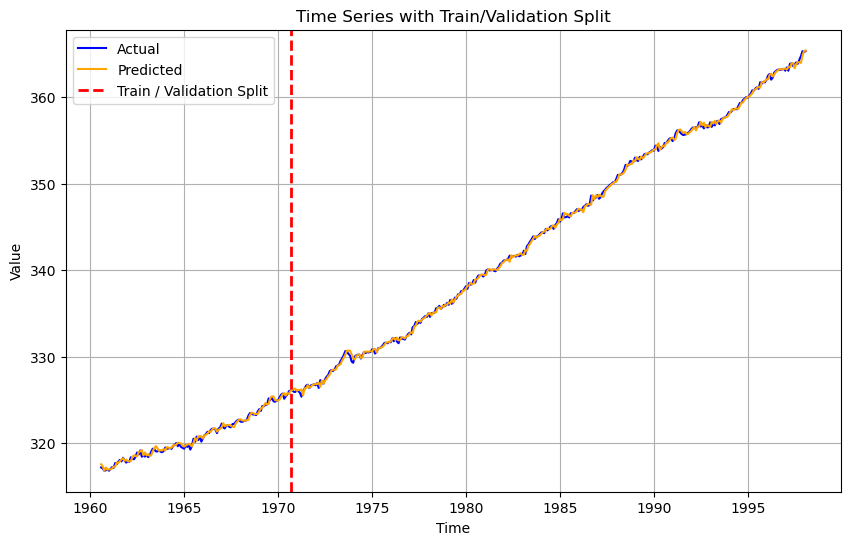

In [906]:
plt.figure(figsize=(10, 6))


plt.plot(date_co2,target_DTR_co2, label="Actual", color="blue")
plt.plot(date_co2,prediction_DTR_co2, label="Predicted", color="orange")


split_index = DTR_co2[DTR_co2["Phase"] == "train"].shape[0]

plt.axvline(
    x=split_index,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Train / Validation Split'
)


plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series with Train/Validation Split")

plt.legend()
plt.grid(True)

plt.show()

<Figure size 1000x600 with 0 Axes>

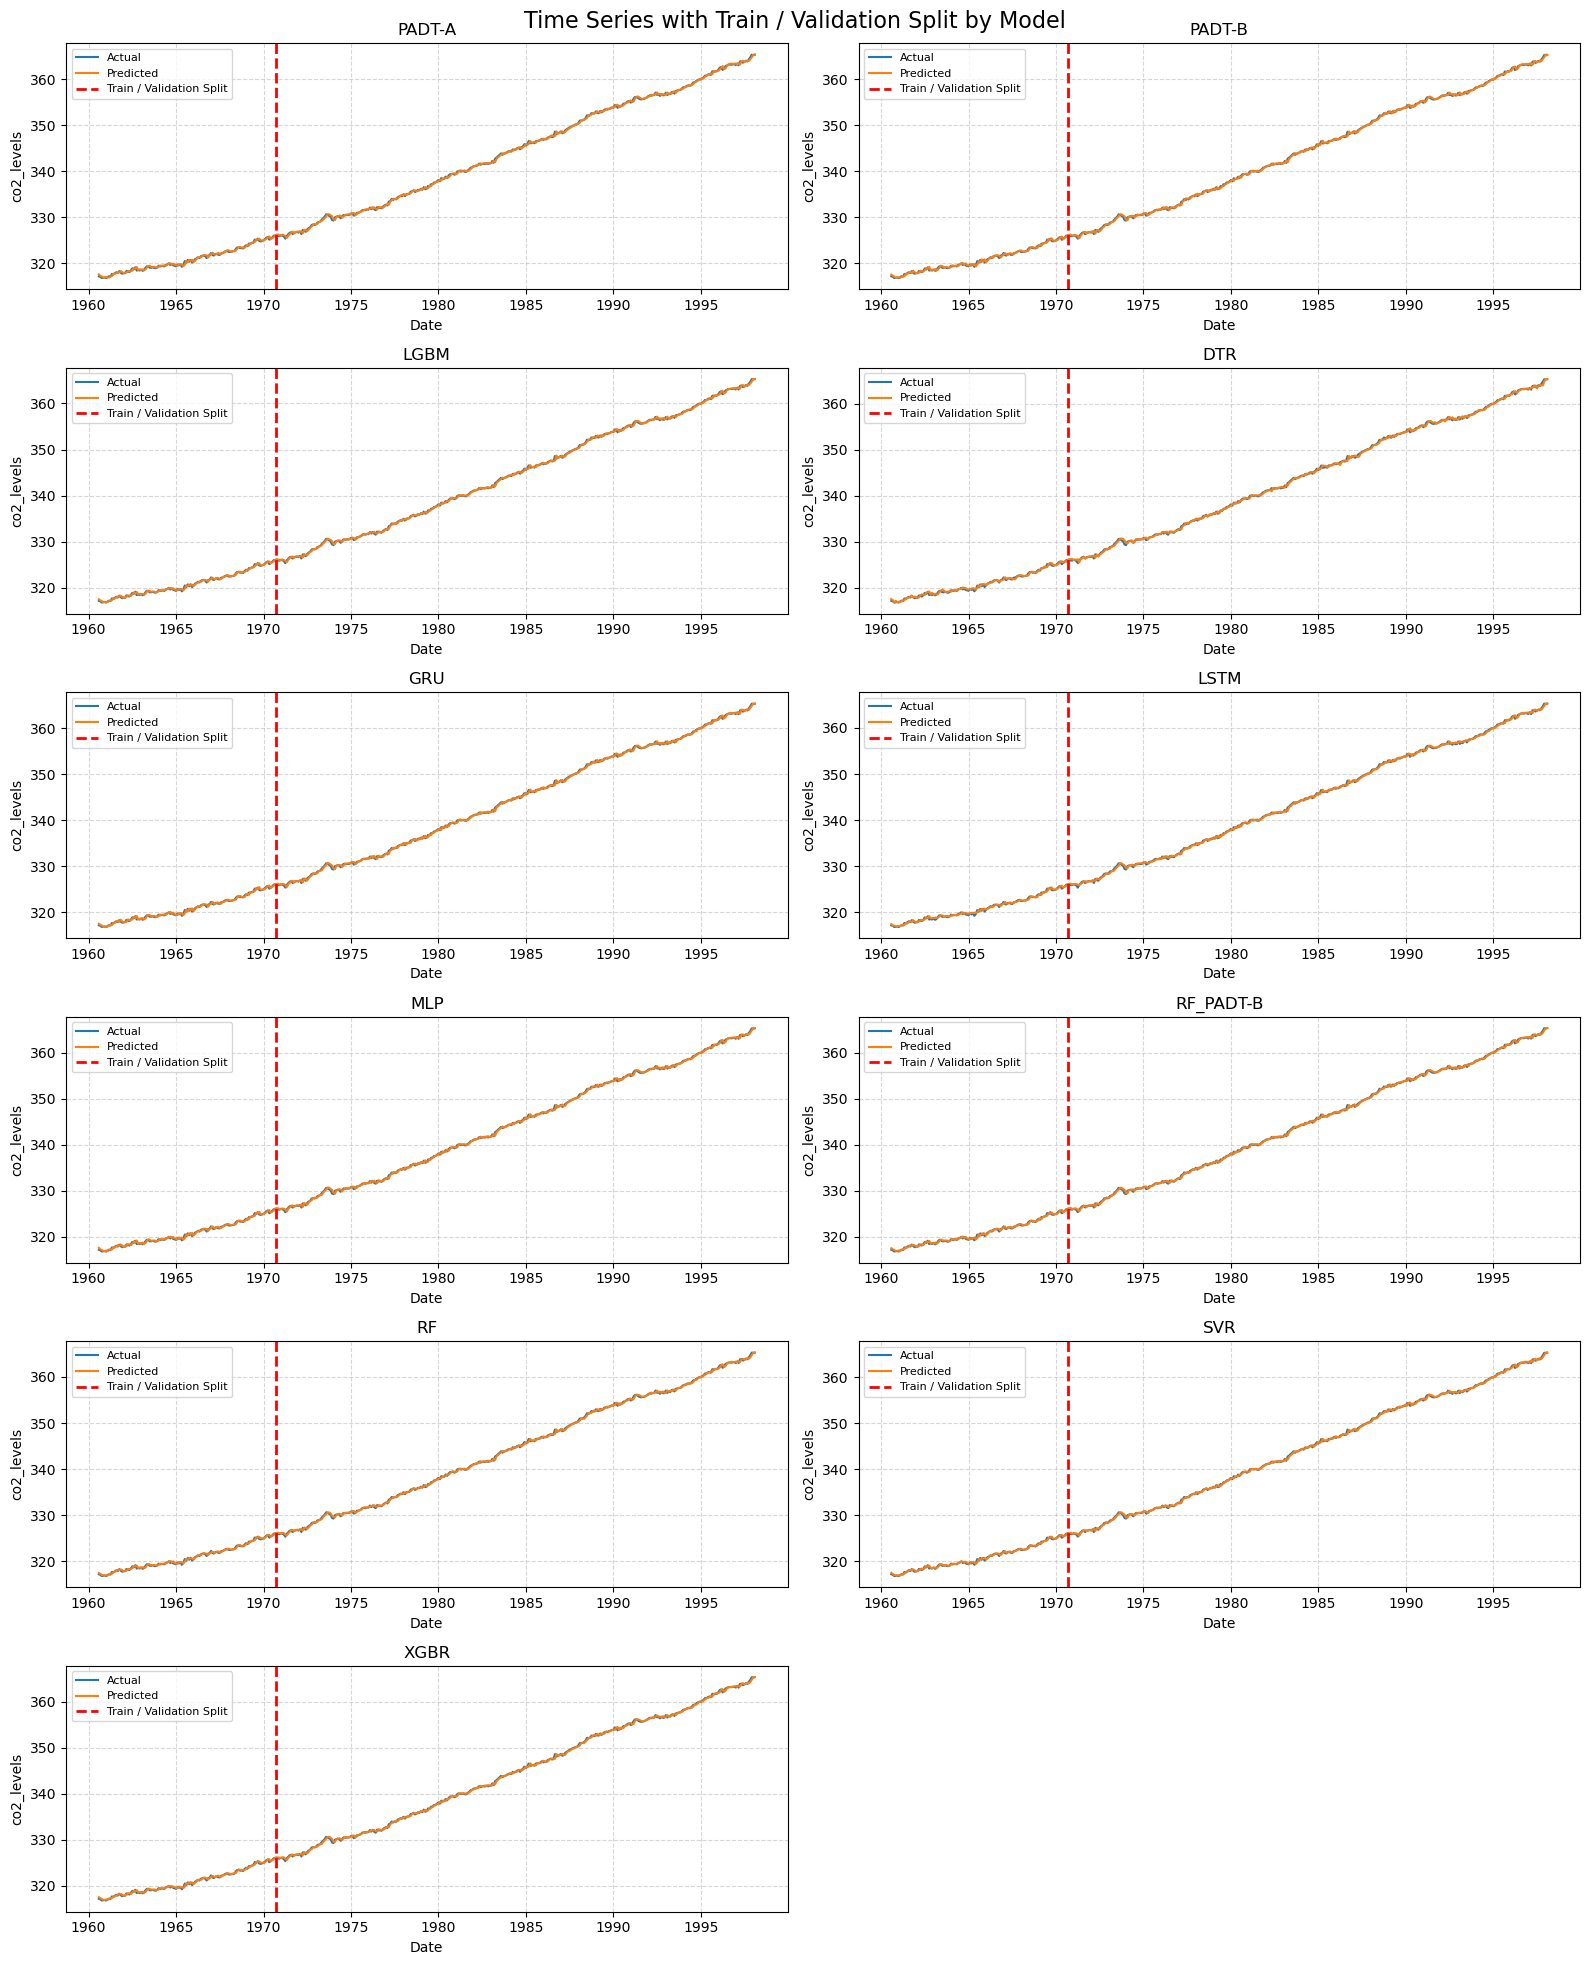

In [ ]:
plt.figure(figsize=(10, 6))


modelos = {
    "PADT-A": padt_A_co2,
    "PADT-B": padt_B_co2,
    "LGBM": lgbm_co2,
    "DTR": DTR_co2,
    "GRU": gru_co2,
    "LSTM": lstm_co2,
    "MLP": mlp_co2,
    "RF_PADT-B": rf_padt_B_co2,
    "RF": rf_co2,
    "SVR": svr_co2,
    "XGBR": xgbr_co2,
}

fig, axes = plt.subplots(6, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (nome_modelo, df_modelo) in enumerate(modelos.items()):
    ax = axes[i]

    split_index = df_modelo[df_modelo["Phase"] == "train"].shape[0]

    ax.plot(DTR_co2["date"], df_modelo["target"], label="Actual", linewidth=1.5)
    ax.plot(DTR_co2["date"],df_modelo["pred"], label="Predicted", linewidth=1.5)

    df_modelo = DTR_co2.sort_values("date").reset_index(drop=True)

    split_index = df_modelo[df_modelo["Phase"] == "val"].index[0]

    ax.axvline(
        x=split_index,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Train / Validation Split"
    )

    ax.set_title(nome_modelo)
    ax.set_xlabel("Date")
    ax.set_ylabel("co2_levels")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

# remove gráfico vazio se sobrar
for j in range(len(modelos), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Time Series with Train / Validation Split by Model", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
'''
platagem de fronteira de decisao para SVM com kernel RBF, variando gamma e C

'''

'''
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Dados parecidos com o livro
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

def plot_decision_boundary(model, X, y, ax, title):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min, x0_max, 400),
        np.linspace(x1_min, x1_max, 400)
    )

    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = model.predict(grid).reshape(xx0.shape)

    ax.contourf(xx0, xx1, pred, alpha=0.3)
    ax.contour(xx0, xx1, pred, linewidths=1)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", label="Classe 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", label="Classe 1")

    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.grid(True)

configs = [
    (0.1, 0.001),
    (0.1, 1000),
    (5, 0.001),
    (5, 1000)
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (gamma, C) in zip(axes.ravel(), configs):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", gamma=gamma, C=C)
    )

    model.fit(X, y)

    plot_decision_boundary(
        model,
        X,
        y,
        ax,
        title=f"gamma = {gamma}, C = {C}"
    )

plt.tight_layout()
plt.show()

'''

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nfrom sklearn.datasets import make_moons\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.svm import SVC\n\n# Dados parecidos com o livro\nX, y = make_moons(n_samples=100, noise=0.15, random_state=42)\n\ndef plot_decision_boundary(model, X, y, ax, title):\n    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5\n    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5\n\n    xx0, xx1 = np.meshgrid(\n        np.linspace(x0_min, x0_max, 400),\n        np.linspace(x1_min, x1_max, 400)\n    )\n\n    grid = np.c_[xx0.ravel(), xx1.ravel()]\n    pred = model.predict(grid).reshape(xx0.shape)\n\n    ax.contourf(xx0, xx1, pred, alpha=0.3)\n    ax.contour(xx0, xx1, pred, linewidths=1)\n\n    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", label="Classe 0")\n    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", label="Classe 1")\n\n    ax.set_title(title)\n    ax.set_x